<a href="https://colab.research.google.com/github/CMDDclass/MS697-material/blob/main/2_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-driven Materials Development

This notebook was prepared with reference to the Machine Learning course materials by Sergei V. Kalinin, University of Tennessee.

!nvidia-smi

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

# Autoencoder

### What is an Autoencoder?

An Autoencoder (AE) is a type of neural network that learns to compress data into a smaller representation and then reconstruct it back to the original form.

It consists of two main components:

• Encoder : Compresses the input into a low-dimensional latent vector

• Decoder : Rebuilds the original data from the latent vector

Unlike supervised learning, an autoencoder does not need labels —
it learns directly from the input data itself (self-supervision).

### Why do we use Autoencoders?

Autoencoders help us:

•	Reduce dimensionality and learn meaningful features

•	Remove noise from images

•	Understand the underlying structure of the data

•	Visualize complex data in a lower-dimensional space
(e.g., 2D latent space for MNIST digits)

### Our Goal in this Exercise

We will:

1.	Build a Convolutional Autoencoder using the MNIST dataset

2.	Compress each digit image into a 2-dimensional latent space

3.	Visualize:

•	Reconstructed images

•	Latent space distribution of digits

•	Decoder outputs across the latent grid

This provides a strong foundation before we introduce Variational Autoencoders (VAEs) and see how probabilistic modeling improves generative capabilities.

# 1. Libraries and Dataset Loading

In this section, we import the required libraries and functions:

•	TensorFlow / Keras layers and models for building neural networks

•	MNIST dataset (handwritten digits) used for training and evaluation

•	NumPy for numerical operations

•	Matplotlib for visualization

•	Keras backend utilities (K) for inspecting intermediate tensor shapes

These imports set up the tools needed to build Autoencoder (AE) and Variational Autoencoder (VAE) architectures.

In [ ]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Conv2D, Flatten
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K

import numpy as np
import matplotlib.pyplot as plt

# Data Loading & Preprocessing

In this step, we load the MNIST handwritten digit dataset and prepare it for training Autoencoders.

•	We subsample the dataset by taking every 10th image to keep the training time short for demonstration.

•	Each image is reshaped to include a channel dimension: (28, 28) → (28, 28, 1)

•	Pixel values are normalized to the range [0, 1] for stable neural network training.

These preprocessed images will serve as both inputs and targets for reconstruction in both AE and VAE models.

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train[0::10]; x_test = x_test[0::10]; y_test = y_test[0::10]
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32')/255
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32')/255

# 2. Model Hyperparameters

Here we define the key hyperparameters for building the Autoencoder and Variational Autoencoder:

•	input_shape — the shape of each MNIST image (28 × 28 × 1)

•	batch_size — number of samples processed per training step

•	kernel_size — size of the convolution filters (3×3)

•	latent_dim — dimensionality of the compressed latent representation
(set to 2 so we can visualize the latent space in 2D)

•	layer_filters — number of convolution filters in each encoder layer
([32, 64] → two Conv layers with increasing depth)

These settings control the model structure and directly influence both reconstruction performance and training behavior.

In [ ]:
input_shape = (28, 28, 1)
batch_size=32
kernel_size=3
latent_dim=2
layer_filters = [32, 64]

# 3. Building the Encoder Network (AE)

We construct the encoder part of the Autoencoder, which compresses an MNIST image into a 2-dimensional latent vector.

Steps:
1.	Input Layer receives a 28×28 grayscale image.

2.	Two convolutional layers (Conv2D) with stride 2 gradually reduce the spatial size:
    28 → 14 → 7 while increasing feature depth.

3.	We record the resulting shape (7×7×64) for use later in the decoder.

4.	The feature map is flattened into a 1D vector.

5.	A final Dense layer produces the latent code of size latent_dim = 2.

This encoder learns how to extract and compress essential visual features into a low-dimensional representation.

In [ ]:
inputs = Input(shape=input_shape)
x = inputs
for filters in [32, 64]:
    x = Conv2D(filters, kernel_size=3, activation='relu', strides=2, padding='same')(x)
shape = K.int_shape(x)   # (None, 7, 7, 64)
x = Flatten()(x)
latent = Dense(latent_dim, name='latent_vector')(x)
encoder = Model(inputs, latent, name='encoder')

# 4. Building the Decoder Network (AE)

The decoder reconstructs an image from the compressed latent vector.

Process:
1.	Latent input: A 2-D vector is fed into the decoder.

2.	A fully-connected layer expands this vector into 7×7×64 features — restoring the spatial structure learned by the encoder.

3.	The tensor is reshaped into a feature map.

4.	We apply two transposed convolution layers (Conv2DTranspose) to progressively upsample:
7 → 14 → 28

5.	A final Conv2DTranspose with a sigmoid activation outputs a reconstructed 28×28×1 image.

The decoder learns to turn the compact latent representation back into an image that resembles the original MNIST digit.

In [ ]:
latent_inputs = Input(shape=(2,))
x = Dense(7*7*64)(latent_inputs)
x = Reshape((7, 7, 64))(x)
for filters in [64, 32]:
    x = Conv2DTranspose(filters, kernel_size=3, activation='relu', strides=2, padding='same')(x)
outputs = Conv2DTranspose(1, kernel_size=3, activation='sigmoid', padding='same', name='decoder_output')(x)
decoder = Model(latent_inputs, outputs)

# 5. Training the Autoencoder

Now we combine the encoder and decoder into a full Autoencoder model:

1.	The model takes an input image and encodes it into a 2-D latent vector.

2.	The decoder reconstructs the image from this compressed representation.

3.	We train the network by comparing the output to the original image.

Training settings:

•	Loss: Mean Squared Error (MSE) — measures pixel-level reconstruction quality

•	Optimizer: Adam — adaptive gradient method for stable learning

•	Epochs: 10 (short demo run)

•	Validation: use test data to monitor reconstruction performance

Because the target output is the input image itself, this is self-supervised learning.
After training, we can evaluate how well the model has learned compressed image representations.

In [ ]:
autoencoder = Model(inputs, decoder(encoder(inputs)), name='autoencoder')
autoencoder.compile(loss='mse', optimizer='adam')
autoencoder.fit(x_train, x_train, validation_data=(x_test, x_test),
                epochs=10, batch_size=32)

Epoch 1/10
188/188 [==============================] - 3s 13ms/step - loss: 0.0809 - val_loss: 0.0601
Epoch 2/10
188/188 [==============================] - 2s 10ms/step - loss: 0.0533 - val_loss: 0.0549
Epoch 3/10
188/188 [==============================] - 2s 11ms/step - loss: 0.0510 - val_loss: 0.0533
Epoch 4/10
188/188 [==============================] - 2s 11ms/step - loss: 0.0495 - val_loss: 0.0517
Epoch 5/10
188/188 [==============================] - 2s 10ms/step - loss: 0.0483 - val_loss: 0.0506
Epoch 6/10
188/188 [==============================] - 2s 10ms/step - loss: 0.0472 - val_loss: 0.0499
Epoch 7/10
188/188 [==============================] - 2s 10ms/step - loss: 0.0465 - val_loss: 0.0493
Epoch 8/10
188/188 [==============================] - 2s 10ms/step - loss: 0.0460 - val_loss: 0.0487
Epoch 9/10
188/188 [==============================] - 2s 11ms/step - loss: 0.0456 - val_loss: 0.0484
Epoch 10/10
188/188 [==============================] - 2s 12ms/step - loss: 0.0452 - val_lo

# 6. Visualizing Original Test Images

Before evaluating the Autoencoder’s output, we first display a small batch of 16 original MNIST test images:

•	We select the first 16 images from the test set.

•	These are arranged into a 4×4 grid for easier inspection.

•	The plot is displayed in grayscale and saved as input.png.

This serves as a visual baseline so we can later compare how accurately the Autoencoder reconstructs the digits.

(4, 4, 28, 28)


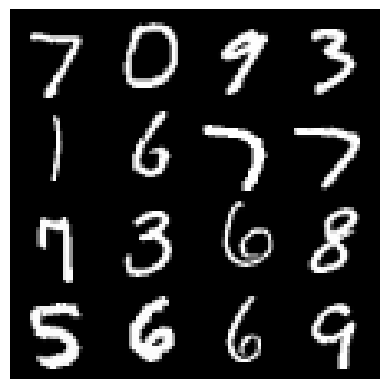

In [ ]:
imgs = x_test[:16]
image_size = 28
imgs = imgs.reshape((4, 4, image_size, image_size))
print(imgs.shape)
imgs = np.vstack([np.hstack(i) for i in imgs])

plt.figure()
plt.axis('off')
plt.imshow(imgs, interpolation='none', cmap='gray')
plt.savefig('input.png')
plt.show()

# 7. Reconstructed Images from the Autoencoder

Next, we feed the test images through the trained Autoencoder to check how well it can reconstruct unseen digits:

•	The model predicts reconstructed versions of the test set.

•	We visualize the first 16 decoded images in the same 4×4 grid format as before.

•	The result is saved as decoded.png for comparison.

If training is successful, the reconstructed digits should closely resemble the original input images — even though the network has compressed them into a 2-D latent space along the way.

32/32 [==============================] - 0s 6ms/step
(4, 4, 28, 28)


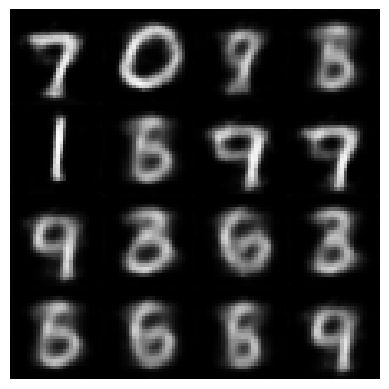

In [ ]:
# predict the autoencoder output from test data
x_decoded = autoencoder.predict(x_test)

# display the 1st 8 test input and decoded images
imgs = x_decoded[:16]
image_size = 28
imgs = imgs.reshape((4, 4, image_size, image_size))
print(imgs.shape)
imgs = np.vstack([np.hstack(i) for i in imgs])

plt.figure()
plt.axis('off')
plt.imshow(imgs, interpolation='none', cmap='gray')
plt.savefig('decoded.png')
plt.show()

# 8. Visualizing the Latent Space

To understand how the Autoencoder organizes information, we project test images into the 2-D latent space using the encoder.

What we do here:

•	Pass all test samples through the encoder to obtain their 2-D latent codes

•	Plot the resulting points in a scatter plot

•	Color each point according to its true label (digit 0–9)

If the encoder has learned meaningful features, digits with similar shapes should form clusters in latent space.
This visualization helps us check how well the compressed representation separates different digit classes.

32/32 [==============================] - 0s 2ms/step


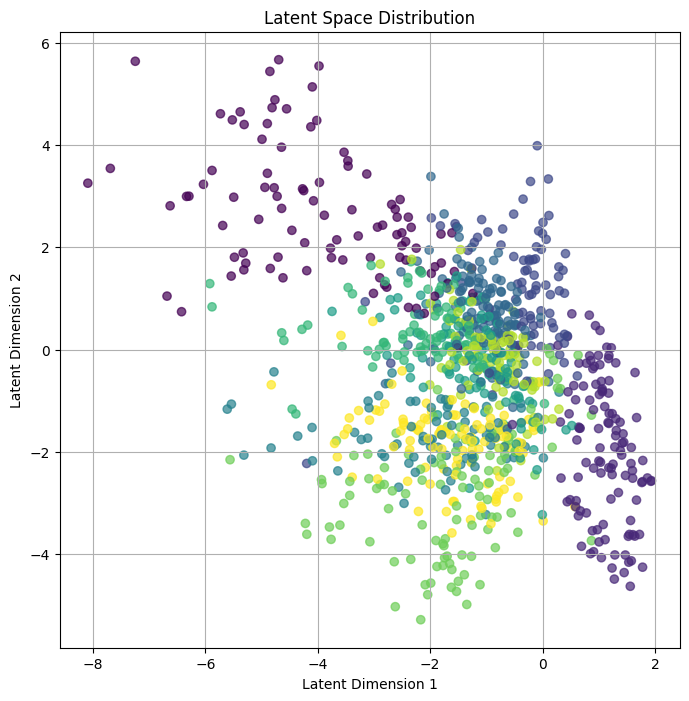

In [ ]:
import matplotlib.pyplot as plt

def plot_latent_distribution(data, labels, encoder):
    """
    Plots the latent distribution of the data using a 2D latent space.

    Parameters:
    - data: The input data to encode and plot.
    - encoder: The encoder model with a `predict` method that encodes data into a 2D latent space.
    """

    # Use the encoder to transform the data into the latent space
    latent_variables = encoder.predict(data)

    # Check if the latent space is 2D
    if latent_variables.shape[1] != 2:
        raise ValueError("The latent space is not 2D.")

    # Plotting the latent space distribution
    plt.figure(figsize=(8, 8))
    plt.scatter(latent_variables[:, 0], latent_variables[:, 1], c = labels, alpha=0.7)
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    plt.title('Latent Space Distribution')
    plt.grid(True)
    plt.show()

plot_latent_distribution(x_test, y_test, encoder)

# 9. Generating Images from Latent Space Samples

To explore what the Autoencoder has learned, we directly sample points from the 2-D latent space and decode them into images.

What this visualization shows:

•	We define a grid of points across the latent space

•	Each point is passed into the decoder

•	The output images are arranged into a visual grid

This allows us to examine how small movements in the latent space produce smooth transitions in the generated digits.
It highlights whether the learned representation is continuous and whether different digit classes occupy distinct regions.


1/1 [==============================] - 0s 10ms/step


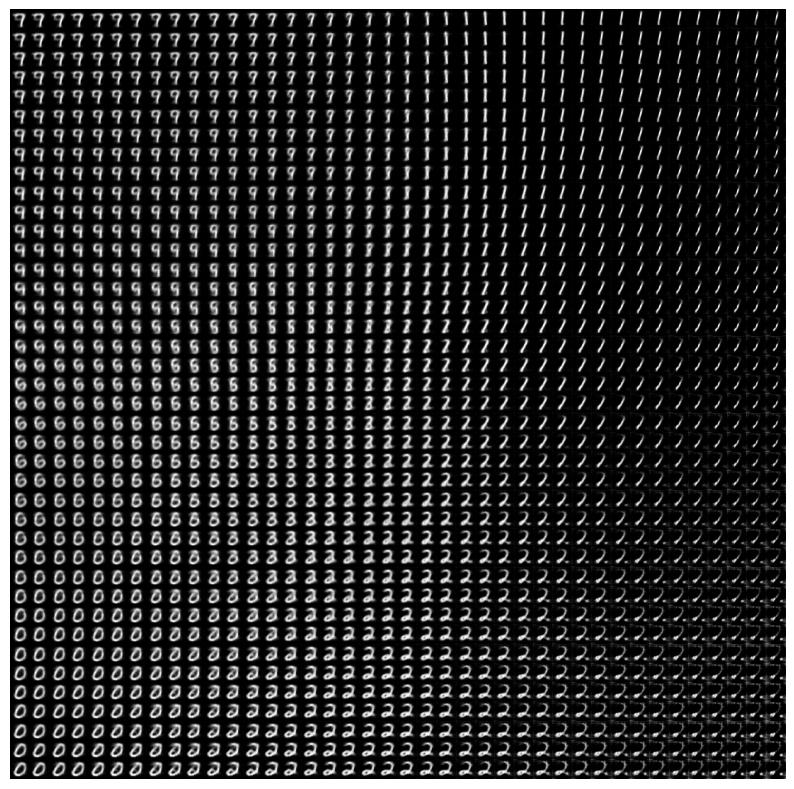

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_latent_space(decoder, num_samples=10, grid_range=3, image_size=(28, 28)):
    """
    Generates a grid of images decoded from latent space points.

    Parameters:
    - decoder: The decoder model that decodes latent points into images.
    - num_samples: The number of images per dimension in the grid.
    - grid_range: The range of values in each dimension of the latent space grid.
    - image_size: A tuple (height, width) of the images.
    """

    # Linearly spaced coordinates corresponding to the 2D grid
    grid_x = np.linspace(-grid_range, grid_range, num_samples)
    grid_y = np.linspace(-grid_range, grid_range, num_samples)

    # Create a figure with subplots
    figure, axes = plt.subplots(num_samples, num_samples, figsize=(10, 10))

    # Remove inner axes numbers
    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    # Plotting the grid
    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample)
            img = x_decoded[0].reshape(image_size)  # Adjust the shape based on your data
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')

    # Adjust the spacing between plots
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

# Usage example (assuming your decoder is named 'decoder'):
# plot_latent_space(decoder, num_samples=10, grid_range=3, image_size=(28, 28))
plot_latent_space(decoder, num_samples=40, grid_range=3)

# Variational Autoencoder (VAE)

### What is a Variational Autoencoder (VAE)?

A Variational Autoencoder (VAE) is an extension of the Autoencoder that learns a probabilistic latent space instead of a fixed compressed vector like in a standard AE.

Key Idea

Instead of encoding each image into a single point,
the VAE encodes it into a distribution:

$$
q(z|x) \sim \mathcal{N}(\mu(x), \sigma^2(x))
$$

- Encoder outputs a mean ($\mu$) and log-variance ($\log \sigma^2$)
- We sample from this distribution to get $z$
- Decoder reconstructs the input from sampled $z$

This gives VAE generative power → we can sample new images by sampling $z$!

Learning Objective (Loss Function)

VAE minimizes:

$$
\underbrace{\text{Reconstruction Loss}}{\text{make output like input}}
\;+\;
\underbrace{D{KL}(q(z|x) || p(z))}_{\text{organize latent space}}
$$
The KL divergence encourages the latent space to follow a normal distribution, allowing continuous exploration of the latent space.

What we will do now

We will:

1. Build a VAE using the same CNN structure as the AE

2. Compare VAE vs AE reconstruction quality

3. Visualize and analyze the 2D latent space

4. Improve VAE performance by tuning:

	•	latent dimension

	•	training epochs

	•	KL weight warm-up (β-VAE)

	•	loss function (MSE → BCE)



# 1. Libraries and Dataset Loading
We import the essential libraries to build and train Variational Autoencoders (VAE):

•	Keras / TensorFlow layers: Dense, Conv2D, Conv2DTranspose, Flatten, Reshape, Input for the encoder/decoder architecture

•	Model: functional API for defining the VAE components (encoder, decoder, end-to-end model)

•	MNIST: convenient 28\times28 grayscale dataset for representation learning and generation

•	Keras backend (K): utilities such as K.int_shape to capture intermediate tensor shapes for the decoder

•	TensorFlow (tf): low-level ops and random sampling (used in the reparameterization trick)

•	NumPy / Matplotlib: array manipulation and visualization (original images, reconstructions, latent space grids)

In [ ]:
from tensorflow.keras.layers import Lambda, Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.losses import mse
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K

import numpy as np
import matplotlib.pyplot as plt
import argparse
import os

# 2. Preparing the MNIST Dataset for VAE

Just like in the Autoencoder experiment, we load and preprocess the MNIST handwritten digit dataset as the input for our VAE.

Processing steps:

1.	Load the MNIST dataset into training and test sets

2.	Subsample the data using every 10th sample to keep training lightweight

3.	Reshape each image to include a channel dimension:
(28, 28) \rightarrow (28, 28, 1)

4.	Convert pixel intensities to floats and normalize to [0, 1]

This ensures the data is properly formatted for the convolutional neural network and allows the VAE to learn from the same inputs used in the AE baseline.

In [ ]:
# MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

image_size = x_train.shape[1]
original_dim = image_size * image_size
x_train = np.reshape(x_train, [-1, original_dim])
x_test = np.reshape(x_test, [-1, original_dim])
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# 3. VAE Hyperparameters

We configure the core settings for our convolutional VAE:

•	input_shape: (28, 28, 1) — MNIST grayscale image size

•	kernel_size: 3 — size of convolution filters (3×3)

•	layer_filters: [32, 64] — two Conv blocks with increasing channels (downsample 28→14→7)

•	latent_dim: 2 — 2-D latent space for easy visualization (μ, σ live in this space)

•	batch_size: 32 — samples per gradient step

•	epochs: 10 — short demo run; we’ll increase this later when tuning

In [ ]:
# network parameters
input_shape = (original_dim, )
intermediate_dim = 512
batch_size = 128
latent_dim = 2
epochs = 10

# 4. Reparameterization Trick (Sampling Layer)

In a VAE, the encoder does not output a single latent vector.
Instead, it predicts a distribution:
$$
q(z|x) = \mathcal{N}(\mu(x), \sigma^2(x))
$$
To draw samples from this distribution while keeping backpropagation possible, we use the reparameterization trick:
$$
z = \mu + \sigma \odot \epsilon,\quad \epsilon \sim \mathcal{N}(0, I)
$$
This custom Keras Sampling layer:

Takes $(z_{\text{mean}}, z_{\log \text{var}})$ from the encoder

Samples a latent vector z using the equation above
Adds the KL divergence loss:
$$
D_{KL}(q(z|x)\,\|\,\mathcal{N}(0,I))
$$
which encourages the latent space to follow a standard normal distribution

This regularization is what gives VAE the ability to interpolate smoothly and generate new data from the latent space.

In [ ]:
def sampling(args):
    """Reparameterization trick by sampling
        fr an isotropic unit Gaussian.
    # Arguments:
        args (tensor): mean and log of variance of Q(z|X)
    # Returns:
        z (tensor): sampled latent vector
    """

    z_mean, z_log_var = args
    # K is the keras backend
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    # by default, random_normal has mean=0 and std=1.0
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

# 5. VAE Encoder — From Images to Latent Distributions

The encoder network transforms an input image into the parameters of a Gaussian distribution in a low-dimensional latent space.

Workflow:
1.	Input image (28×28×1)

2.	Two convolutional layers
→ progressively extract features and downsample (28→14→7)

3.	Flatten to a vector

4.	Produce two outputs:
•	z_{\text{mean}}: the center of the latent distribution
•	z_{\log \text{var}}: log-variance for stability in training

5.	Pass both into the Sampling layer to generate a latent vector z

We create two encoder models:

•	encoder_full: returns $[z_{\text{mean}}, z_{\log \text{var}}, z]$ — used during training

•	encoder: returns only $(z_{\text{mean}})$ — used later for clean visualization of the latent space

This probabilistic encoder is what gives the VAE its generative power:
it learns how each digit varies, not just how to compress it.

In [ ]:
# VAE model = encoder + decoder
# build encoder model
inputs = Input(shape=input_shape, name='encoder_input')
x = Dense(intermediate_dim, activation='relu')(inputs)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)

# use reparameterization trick to push the sampling out as input
# note that "output_shape" isn't necessary
# with the TensorFlow backend
z = Lambda(sampling,
           output_shape=(latent_dim,),
           name='z')([z_mean, z_log_var])

# instantiate encoder model
encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()
plot_model(encoder,
           to_file='vae_mlp_encoder.png',
           show_shapes=True)


Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 784)]                0         []                            
                                                                                                  
 dense_38 (Dense)            (None, 512)                  401920    ['encoder_input[0][0]']       
                                                                                                  
 z_mean (Dense)              (None, 2)                    1026      ['dense_38[0][0]']            
                                                                                                  
 z_log_var (Dense)           (None, 2)                    1026      ['dense_38[0][0]']            
                                                                                            

# 6. VAE Decoder — From Latent Space Back to Images

The decoder network reconstructs an image from a sampled latent vector z.
In contrast to the encoder, the decoder upsamples the representation:

Process:
1.	Input a latent vector of dimension latent_dim = 2

2.	Use a fully connected layer to expand into a feature map shape
(7, 7, 64) — the inverse of the encoder bottleneck

3.	Apply transposed convolutions (Conv2DTranspose) to upsample:
•	7 → 14 → 28 (spatial resolution restored)

4.	A final Conv2DTranspose layer with sigmoid activation generates
a reconstructed (28×28×1) grayscale MNIST digit

The decoder learns to map points in latent space into realistic digit images.
By sampling different z values, we can generate new digits — a key advantage of VAEs over standard AEs.

In [ ]:
# build decoder model
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
x = Dense(intermediate_dim, activation='relu')(latent_inputs)
outputs = Dense(original_dim, activation='sigmoid')(x)

# instantiate decoder model
decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()
plot_model(decoder,
           to_file='vae_mlp_decoder.png',
           show_shapes=True)



Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_sampling (InputLayer)     [(None, 2)]               0         
                                                                 
 dense_39 (Dense)            (None, 512)               1536      
                                                                 
 dense_40 (Dense)            (None, 784)               402192    
                                                                 
Total params: 403728 (1.54 MB)
Trainable params: 403728 (1.54 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


# 7. Building the Full VAE Model

Here, we connect the encoder and decoder into a complete end-to-end Variational Autoencoder:
1.	The encoder produces three outputs:

    •	$z_{\text{mean}}$

    •	$z_{\log \text{var}}$

    •	sampled latent vector z

2.	Only the sampled vector z is passed into the decoder

3.	The VAE outputs a reconstructed image shaped like the input

We compile the model using:

•	Reconstruction loss: mse (mean squared error)

•	KL divergence loss: automatically added inside the Sampling layer
during the forward pass

This design allows the VAE to simultaneously:

•   Reconstruct digit images

•   Learn a structured, continuous latent space suitable for sampling and generation

In [ ]:
# instantiate VAE model
outputs = decoder(encoder(inputs)[2])
vae = Model(inputs, outputs, name='vae_mlp')
reconstruction_loss = mse(inputs, outputs)
reconstruction_loss *= original_dim
kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
kl_loss = K.sum(kl_loss, axis=-1)
kl_loss *= -0.5
vae_loss = K.mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)
vae.compile(optimizer='adam')
vae.summary()

Model: "vae_mlp"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 784)]                0         []                            
                                                                                                  
 encoder (Functional)        [(None, 2),                  403972    ['encoder_input[0][0]']       
                              (None, 2),                                                          
                              (None, 2)]                                                          
                                                                                                  
 decoder (Functional)        (None, 784)                  403728    ['encoder[0][2]']             
                                                                                            

# 8. Training the VAE

We train the VAE to reconstruct its input images.
Since the model learns a latent distribution, it optimizes two objectives together:

•   Reconstruction Loss (mse) : Makes the output image look like the input

•   KL Divergence Loss : Regularizes the latent space into a smooth Gaussian structure

During training:

•	Inputs = Outputs (self-supervised learning)

•	Validation is performed on the MNIST test set

•	Loss represents the sum of both reconstruction and KL terms

After this training stage, the VAE has learned:

•   How digits are represented and compressed

•   How to generate variations through sampling in latent space

In [ ]:
vae.fit(x_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, None))

Epoch 1/10
469/469 [==============================] - 3s 6ms/step - loss: 42.7877 - val_loss: 42.3456
Epoch 2/10
469/469 [==============================] - 3s 6ms/step - loss: 42.0899 - val_loss: 41.7505
Epoch 3/10
469/469 [==============================] - 3s 7ms/step - loss: 41.5862 - val_loss: 41.3501
Epoch 4/10
469/469 [==============================] - 3s 6ms/step - loss: 41.1489 - val_loss: 40.9657
Epoch 5/10
469/469 [==============================] - 3s 6ms/step - loss: 40.7339 - val_loss: 40.6770
Epoch 6/10
469/469 [==============================] - 3s 6ms/step - loss: 40.3630 - val_loss: 40.2108
Epoch 7/10
469/469 [==============================] - 3s 6ms/step - loss: 40.0485 - val_loss: 40.0337
Epoch 8/10
469/469 [==============================] - 3s 6ms/step - loss: 39.7398 - val_loss: 39.7691
Epoch 9/10
469/469 [==============================] - 3s 7ms/step - loss: 39.5045 - val_loss: 39.4786
Epoch 10/10
469/469 [==============================] - 3s 6ms/step - loss: 39.2762

# 9. Visualizing Original Test Images

Before evaluating the Autoencoder’s output, we first display a small batch of 16 original MNIST test images:

•	We select the first 16 images from the test set.

•	These are arranged into a 4×4 grid for easier inspection.

•	The plot is displayed in grayscale and saved as input.png.

This serves as a visual baseline so we can later compare how accurately the Autoencoder reconstructs the digits.

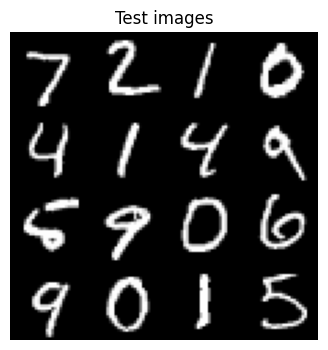

In [ ]:
def show_grid(imgs, grid=(4,4), fname=None, title=None, image_size=28):
    imgs = np.asarray(imgs)

    # (N, H, W, 1) -> (N, H, W)
    if imgs.ndim == 4 and imgs.shape[-1] == 1:
        imgs = imgs[..., 0]

    # (N, 784) -> (N, 28, 28)
    if imgs.ndim == 2 and imgs.shape[1] == image_size * image_size:
        imgs = imgs.reshape(-1, image_size, image_size)

    # 최소 (N,H,W) 보장
    if imgs.ndim != 3:
        raise ValueError(f"Expected (N,H,W) or (N,H,W,1) or (N,{image_size*image_size}), got {imgs.shape}")

    r, c = grid
    N, H, W = imgs.shape
    assert r * c <= N, f"grid {grid} requires at least {r*c} images, got {N}"

    canvas = np.vstack([
        np.hstack([imgs[i*c + j] for j in range(c)])
        for i in range(r)
    ])

    plt.figure(figsize=(c, r))
    plt.axis('off')
    if title: plt.title(title)
    plt.imshow(canvas, cmap='gray', vmin=0, vmax=1)
    if fname:
        plt.savefig(fname, bbox_inches='tight', pad_inches=0)
    plt.show()
show_grid(x_test[:16], grid=(4,4), title='Test images')

# 10. Reconstructed Images from the VAE

Now we evaluate how well the VAE can reconstruct unseen test images.

•	We pass the test set through the trained VAE to obtain reconstructed images.

•	We display the first 16 decoded images arranged in a 4×4 grid.

•	These results are also saved as "vae_decoded.png" for later comparison.

Since the VAE learns a probabilistic latent space, its reconstructions may appear slightly blurrier than those from the AE —
a common trade-off for better generative capabilities.


40/40 [==============================] - 0s 3ms/step


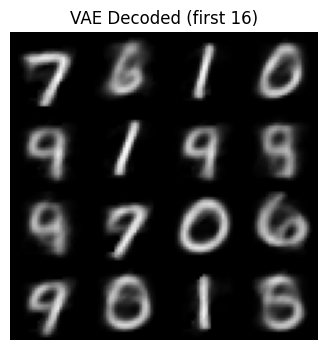

In [ ]:
x_decoded = vae.predict(x_test, batch_size=256)
show_grid(x_decoded[:16], grid=(4,4), fname='vae_decoded.png', title='VAE Decoded (first 16)')

# Practice: Tune VAE Hyperparameters

In this section, we experiment with different hyperparameters of the Variational Autoencoder and observe how they affect the reconstruction quality and latent space structure.

We encourage you to run multiple settings and compare your results!


| Hyperparameter   | Description                               | Suggested Values       | Expected Effect |
|-----------------|-------------------------------------------|------------------------|----------------|
| intermediate_dim | Size of the hidden (dense) layer          | 256 / 512 / 1024       | Larger → more expressive encoder/decoder → clearer reconstructions |
| batch_size       | Number of samples per gradient update     | 64 / 128 / 256         | Smaller → noisy updates, maybe better generalization but slower |
| latent_dim       | Dimensionality of the latent space        | 2 / 8 / 16             | Larger → more information preserved → better reconstructions but harder to visualize |
| epochs           | Number of training iterations             | 20 / 40 / 60           | Longer → more convergence → reduced reconstruction error |

### **Submit the following as your practice result:

•	Reconstructed digit images showing successful generation of MNIST test data using VAE

•	The hyperparameter set (intermediate_dim / batch_size / latent_dim / epochs) that produced the shown results

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 784)]                0         []                            
                                                                                                  
 dense_82 (Dense)            (None, 1024)                 803840    ['encoder_input[0][0]']       
                                                                                                  
 z_mean (Dense)              (None, 16)                   16400     ['dense_82[0][0]']            
                                                                                                  
 z_log_var (Dense)           (None, 16)                   16400     ['dense_82[0][0]']            
                                                                                            

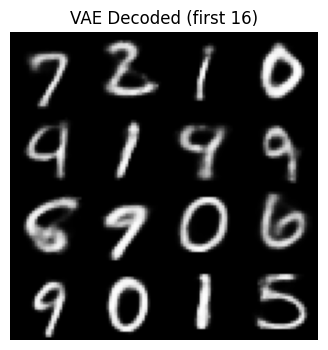

In [ ]:
# You can change these parameters and see how the results differ
intermediate_dim = 1024  # 256, 512, 1024
batch_size = 64        # 32, 64, 256
latent_dim = 16          # 2, 8, 16
epochs = 40             # 10 ~

# Don't change this part
#------------------------------------------------------------------#
# VAE model = encoder + decoder
# build encoder model
inputs = Input(shape=input_shape, name='encoder_input')
x = Dense(intermediate_dim, activation='relu')(inputs)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)

# use reparameterization trick to push the sampling out as input
# note that "output_shape" isn't necessary
# with the TensorFlow backend
z = Lambda(sampling,
           output_shape=(latent_dim,),
           name='z')([z_mean, z_log_var])

# instantiate encoder model
encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()
plot_model(encoder,
           to_file='vae_mlp_encoder.png',
           show_shapes=True)

# build decoder model
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
x = Dense(intermediate_dim, activation='relu')(latent_inputs)
outputs = Dense(original_dim, activation='sigmoid')(x)

# instantiate decoder model
decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()
plot_model(decoder,
           to_file='vae_mlp_decoder.png',
           show_shapes=True)

# instantiate VAE model
outputs = decoder(encoder(inputs)[2])
vae = Model(inputs, outputs, name='vae_mlp')
reconstruction_loss = mse(inputs, outputs)
reconstruction_loss *= original_dim
kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
kl_loss = K.sum(kl_loss, axis=-1)
kl_loss *= -0.5
vae_loss = K.mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)
vae.compile(optimizer='adam')
vae.summary()

vae.fit(x_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, None))

x_decoded = vae.predict(x_test, batch_size=256)
show_grid(x_decoded[:16], grid=(4,4),
          fname='vae_decoded.png',
          title='VAE Decoded (first 16)')
#------------------------------------------------------------------


# Visualizing the VAE Latent Space

To examine how the VAE organizes digit representations, we encode the test images into the 2-D latent space using the encoder’s output mean (z_mean).

This plot shows:

•	Each point represents a test digit projected into the latent space

•	Colors correspond to digit labels (0–9)

•	Similar digits tend to cluster together

•	Different digits spread across distinct regions

This visualization demonstrates that the VAE has learned a structured, continuous latent representation that organizes the MNIST digit variations meaningfully.

In [ ]:
def plot_latent_distribution(data, labels, encoder):
    """
    Plots the latent distribution of the data using a 2D latent space.

    Parameters:
    - data: The input data to encode and plot.
    - encoder: The encoder model with a `predict` method that encodes data into a 2D latent space.
    """

    # Use the encoder to transform the data into the latent space
    latent_variables, _, _ = encoder.predict(data, batch_size=batch_size)

    # Check if the latent space is 2D
    if latent_variables.shape[1] != 2:
        raise ValueError("The latent space is not 2D.")

    # Plotting the latent space distribution
    plt.figure(figsize=(8, 8))
    plt.scatter(latent_variables[:, 0], latent_variables[:, 1], c = labels, alpha=0.7)
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    plt.title('Latent Space Distribution')
    plt.grid(True)
    plt.show()
plot_latent_distribution(x_test, y_test, encoder)

157/157 [==============================] - 0s 1ms/step


ValueError: The latent space is not 2D.

24/24 [==============================] - 0s 2ms/step


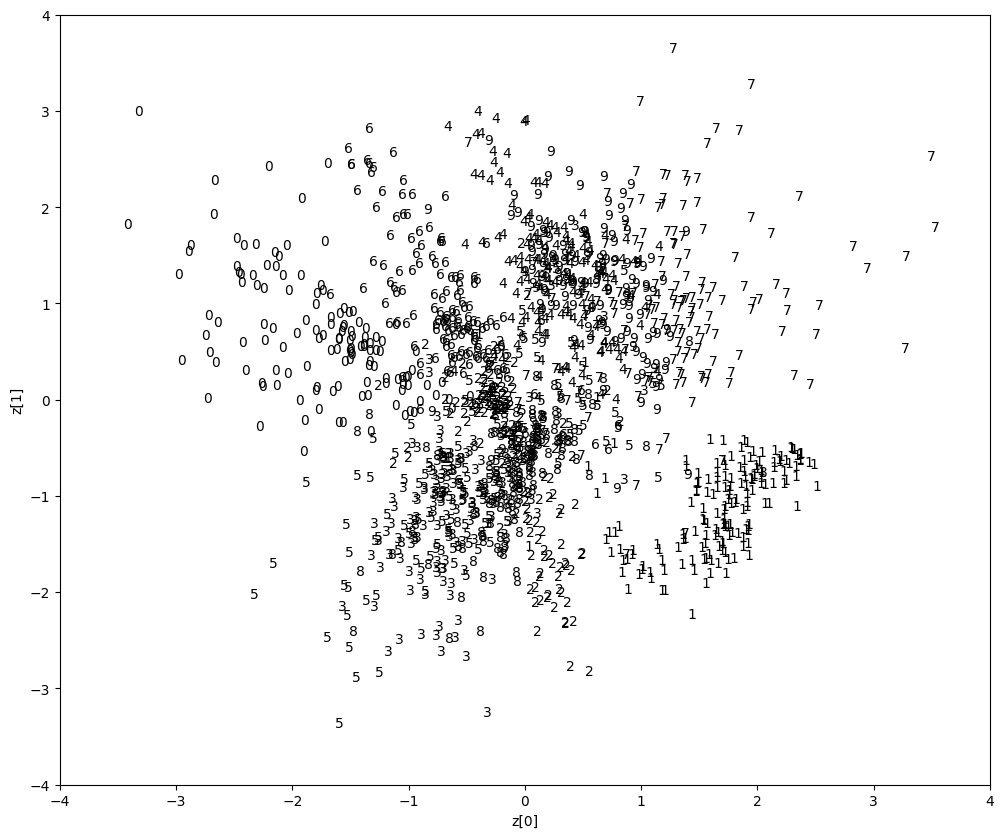

1/1 [==============================] - 0s 11ms/step


KeyboardInterrupt: 

In [ ]:
def plot_results(models,
                 data,
                 batch_size=128,
                 model_name="vae_mnist"):
    """Plots labels and MNIST digits as function
        of 2-dim latent vector
    # Arguments:
        models (tuple): encoder and decoder models
        data (tuple): test data and label
        batch_size (int): prediction batch size
        model_name (string): which model is using this function
    """

    encoder, decoder = models
    x_test, y_test = data
    xmin = ymin = -4
    xmax = ymax = +4
    os.makedirs(model_name, exist_ok=True)

    filename = os.path.join(model_name, "vae_mean.png")
    # display a 2D plot of the digit classes in the latent space
    z, _, _ = encoder.predict(x_test,
                              batch_size=batch_size)
    plt.figure(figsize=(12, 10))

    # axes x and y ranges
    axes = plt.gca()
    axes.set_xlim([xmin,xmax])
    axes.set_ylim([ymin,ymax])

    # subsample to reduce density of points on the plot
    z = z[0::2]
    y_test = y_test[0::2]
    plt.scatter(z[:, 0], z[:, 1], marker="")
    for i, digit in enumerate(y_test):
        axes.annotate(digit, (z[i, 0], z[i, 1]))
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.savefig(filename)
    plt.show()

    filename = os.path.join(model_name, "digits_over_latent.png")
    # display a 30x30 2D manifold of digits
    n = 30
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    # linearly spaced coordinates corresponding to the 2D plot
    # of digit classes in the latent space
    grid_x = np.linspace(-4, 4, n)
    grid_y = np.linspace(-4, 4, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

    plt.figure(figsize=(10, 10))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range + 1
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap='Greys_r')
    plt.savefig(filename)
    plt.show()
models = (encoder, decoder)
data = (x_test[:3000], y_test[:3000])
plot_results(models,
                data,
                batch_size=batch_size,
                model_name="vae_mlp")

In [ ]:
x_test.shape

(10000, 784)

1/1 [==============================] - 0s 10ms/step


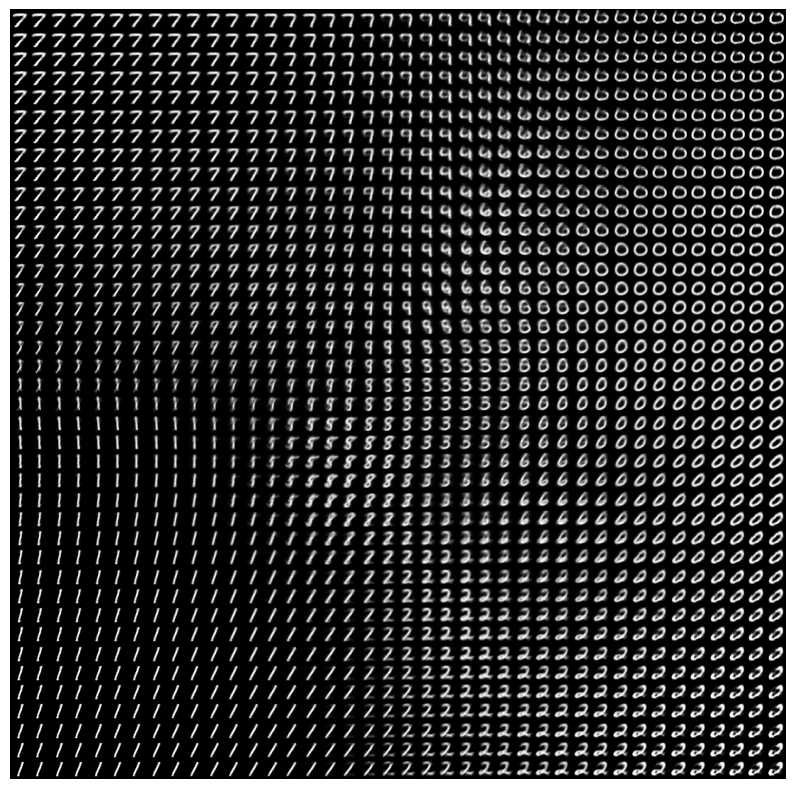

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_latent_space(decoder, num_samples=10, grid_range=3, image_size=(28, 28)):
    """
    Generates a grid of images decoded from latent space points.

    Parameters:
    - decoder: The decoder model that decodes latent points into images.
    - num_samples: The number of images per dimension in the grid.
    - grid_range: The range of values in each dimension of the latent space grid.
    - image_size: A tuple (height, width) of the images.
    """

    # Linearly spaced coordinates corresponding to the 2D grid
    grid_x = np.linspace(-grid_range, grid_range, num_samples)
    grid_y = np.linspace(-grid_range, grid_range, num_samples)

    # Create a figure with subplots
    figure, axes = plt.subplots(num_samples, num_samples, figsize=(10, 10))

    # Remove inner axes numbers
    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    # Plotting the grid
    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder.predict(z_sample);
            img = x_decoded[0].reshape(image_size)  # Adjust the shape based on your data
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')

    # Adjust the spacing between plots
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()
plot_latent_space(decoder, num_samples=40, grid_range=3, image_size=(28, 28))